# Figure: Scalability

This notebook generates computational scalability figures from **Experiment 8** results.

**Inputs**: `../data/results_8/` (JSON files), `../data/instances/2020-08-27.yaml`

**Outputs**:
- `../figures/compute_time.pdf` — Runtime comparison (heuristic vs. exact solver) by number of farmers, log scale
- `../figures/optimality_gap.pdf` — Optimality gap of the heuristic by instance size

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from copy import deepcopy

from farmers_intermediaries import Instance
from road_graphs import RoadGraph
import pickle
import pandas as pd
import pricing
from pricing import Optimizer
from datetime import datetime, timedelta
import numpy as np


json_files = {}
directory = "../data/results_8"

for filename in os.listdir(directory):
    if filename.endswith(".json"):
        filepath = os.path.join(directory, filename)
        with open(filepath, 'r') as file:
            json_files[filename] = json.load(file)

json_files_7 = {}
directory = "../data/results_7"

for filename in os.listdir(directory):
    if filename.endswith(".json"):
        filepath = os.path.join(directory, filename)
        with open(filepath, 'r') as file:
            json_files_7[filename] = json.load(file)

../data/instances/2020-08-27_graph.pkl


/var/folders/8w/9j8h12_n2h7_fp8_7s3fg2zw0000gn/T/ipykernel_18863/2644802434.py:8: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again; shapely 2.1 will not have this compatibility.
  G = pickle.load(pickle_file)


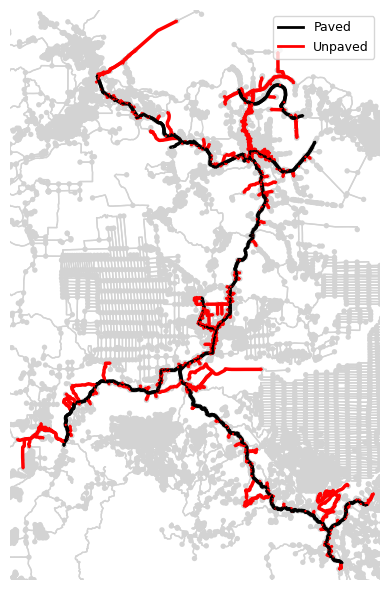

In [2]:
instance_str = "2020-08-27"

graph_data_filename = "../data/instances/"+instance_str+"_graph.pkl"
Platform = Instance.from_yaml('../data/instances/'+instance_str+'.yaml')

if not Platform.load_graph_data(graph_data_filename):
    with open("../data/graph_0-14960_00.pickle", 'rb') as pickle_file:
        G = pickle.load(pickle_file)
    Platform.set_graph(RoadGraph(G))


In [3]:
# We study the gaps
gap_dict = []
for name, result in json_files.items():
    gap_dict.append({
        "instance_str": result["instance_str"],
        "n_farmers": result["n_farmers"],
        "n_intermediaries": result["n_intermediaries"],
        "opt_gap": (result["summary_early_stop"]["forced_upper_bound"] - result["summary_early_stop"]["forced_lower_bound"])/result["summary_early_stop"]["forced_lower_bound"],
        #"upper_bound": result["summary_early_stop"]["forced_upper_bound"]/Platform.USD,
        #"lower_bound": result["summary_early_stop"]["forced_lower_bound"]/Platform.USD,
        "time_suboptimal": result["summary_early_stop"]["total_time"],
        "time_vanilla": None,
    })
df_gaps = pd.DataFrame(gap_dict)

# # Bin epsilon into discrete intervals
# df_gaps["diff_suboptimal"] = (df_gaps["upper_bound"] - df_gaps["lower_bound"]) / df_gaps["lower_bound"]


In [4]:
# We study the gaps
gap_dict_2 = []
for name, result in json_files_7.items():
    gap_dict_2.append({
        "instance_str": result["instance_str"],
        "n_farmers": result["n_farmers"],
        "n_intermediaries": result["n_intermediaries"],
        "opt_gap": None,
        "actual_gap": (result["summary_vanilla"]["max_int_welf_sol"]["profit"] - result["summary_vanilla"]["forced_lower_bound"])/result["summary_vanilla"]["max_int_welf_sol"]["profit"],
        #"lower_bound": result["summary_vanilla"]["forced_lower_bound"]/Platform.USD,
        "time_suboptimal": result["summary_vanilla"]["timestamps"][0],
        "time_vanilla": result["summary_vanilla"]["total_time"],
        #"profit": result["summary_vanilla"]["max_int_welf_sol"]["profit"]/Platform.USD,
    })
df_gaps_2 = pd.DataFrame(gap_dict_2)

In [5]:
all_gaps = pd.concat([df_gaps, df_gaps_2], ignore_index=True)
all_gaps

/var/folders/8w/9j8h12_n2h7_fp8_7s3fg2zw0000gn/T/ipykernel_18863/4227331580.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_gaps = pd.concat([df_gaps, df_gaps_2], ignore_index=True)


,instance_str,n_farmers,n_intermediaries,opt_gap,time_suboptimal,time_vanilla,actual_gap
0,aggregate_instance_4,89,56,-2.215687e-15,298.608612,NaN,NaN
1,aggregate_instance_3,75,42,1.277057e-02,165.965657,NaN,NaN
2,aggregate_instance_1,25,14,1.232334e-01,15.688733,NaN,NaN
3,aggregate_instance_6,134,84,2.844032e-02,1503.723833,NaN,NaN
4,aggregate_instance_7,159,98,3.897113e-02,4820.615320,NaN,NaN
...,...,...,...,...,...,...,...
179,aggregate_instance_2,45,28,NaN,43.604443,65.789245,0.0
180,aggregate_instance_5,116,70,NaN,860.805886,3170.557881,0.0
181,aggregate_instance_2,45,28,NaN,37.346711,55.525573,0.0
182,aggregate_instance_3,75,42,NaN,204.760952,281.717779,0.0


/var/folders/8w/9j8h12_n2h7_fp8_7s3fg2zw0000gn/T/ipykernel_18863/1959568527.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_data_filtered['Time'] = time_data_filtered['Time'] / 60/60  # Convert seconds to minutes


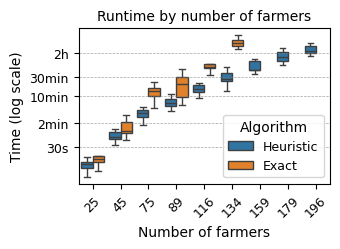

In [6]:
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})


time_data_melted = all_gaps.melt(id_vars='n_farmers', 
                                  value_vars=['time_suboptimal', 'time_vanilla'], 
                                  var_name='Time Type', 
                                  value_name='Time')

# Filter the DataFrame for n_farmers less or equal to 2400
time_data_filtered = time_data_melted[time_data_melted['n_farmers'] <= 200]

# Melt the DataFrame to reshape it for seaborn boxplot
time_data_filtered['Time'] = time_data_filtered['Time'] / 60/60  # Convert seconds to minutes


# Create the boxplot
plt.figure(figsize=(3.5, 2.6))
sns.boxplot(data=time_data_filtered, x='n_farmers', y='Time', hue='Time Type', showfliers=False)

# Set y-axis to log scale
plt.yscale('log')

# Define custom ticks and labels
ticks = [0.5/60, 2/60,  10/60, 30/60, 2]  # 1 minute, 10 minutes, 1 hour, 2 hours in hours
# Filter ticks to include only those that have corresponding labels
labels = ['30s', '2min',  '10min', '30min', '2h']

# Draw horizontal lines at valid ticks
valid_ticks = [tick for tick, label in zip(ticks, labels) if label]

for tick in valid_ticks:
    plt.axhline(y=tick, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.gca().yaxis.set_minor_locator(FixedLocator([]))  # Remove minor ticks
plt.gca().yaxis.set_major_locator(FixedLocator(valid_ticks))
#plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
plt.gca().yaxis.set_major_formatter(FixedFormatter(labels))

plt.title('Runtime by number of farmers')
plt.xlabel('Number of farmers')
plt.ylabel('Time (log scale)')
handles, labels = plt.gca().get_legend_handles_labels()
labels = ['Heuristic' if label == 'time_suboptimal' else 'Exact' if label == 'time_vanilla' else label for label in labels]
plt.legend(handles, labels, title='Algorithm', loc='lower right')
#plt.legend(title='Time Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/compute_time.pdf')
plt.show()



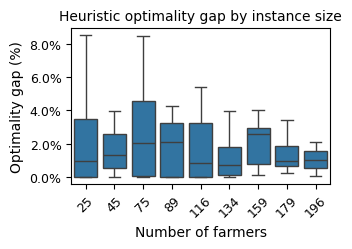

In [7]:
from matplotlib.ticker import PercentFormatter

# Filter the DataFrame for n_farmers less or equal to 2400
gap_data_filtered = all_gaps[all_gaps['n_farmers'] <= 200]

# Create the boxplot for opt_gap
plt.figure(figsize=(3.5, 2.6))
sns.boxplot(data=gap_data_filtered, x='n_farmers', y='opt_gap', showfliers=False)

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.title('Heuristic optimality gap by instance size')
plt.xlabel('Number of farmers')
plt.ylabel('Optimality gap (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/optimality_gap.pdf')
plt.show()